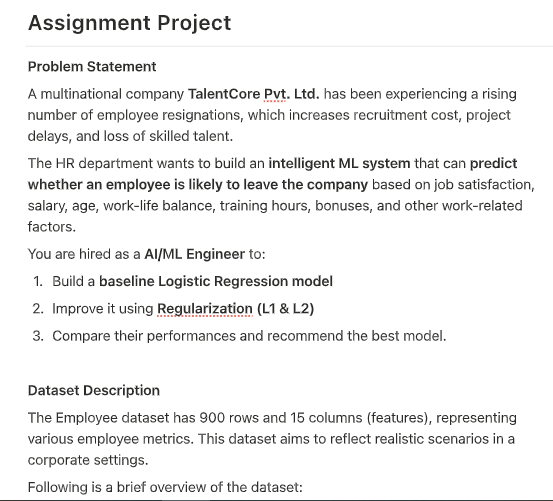

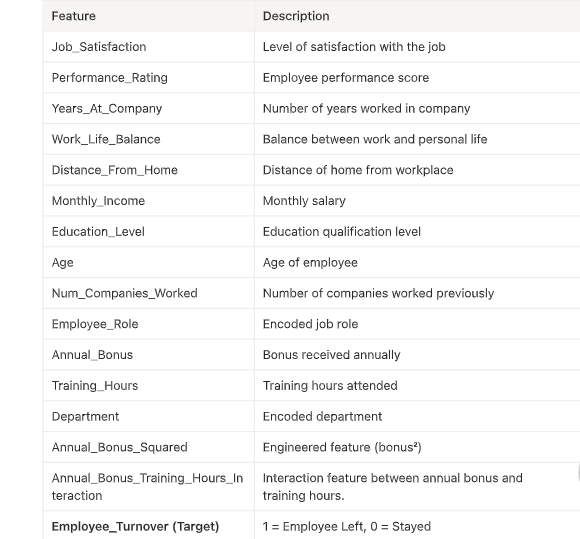

In [2]:
import pandas as pd
df = pd.read_csv("employee_turnover.csv")
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

In [4]:
X = df.drop('Employee_Turnover' , axis=1 )
y = df['Employee_Turnover']

In [5]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.5,random_state=42)

In [6]:
# baseline logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train,y_train)

LogisticRegression(max_iter=200)

In [7]:
# L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5)
lasso.fit(X_train, y_train)

LogisticRegression(C=0.5, penalty='l1', solver='liblinear')

In [8]:
# L2 Regularization (Ridge)
ridge = LogisticRegression(penalty='l2', C=1, max_iter=200)
ridge.fit(X_train, y_train)

LogisticRegression(C=1, max_iter=200)

In [9]:
from sklearn.metrics import accuracy_score, classification_report

models = {'Baseline': lr, 'Lasso': lasso, 'Ridge': ridge}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Baseline
Accuracy: 0.8637037037037038
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       332
           1       0.89      0.84      0.86       343

    accuracy                           0.86       675
   macro avg       0.86      0.86      0.86       675
weighted avg       0.86      0.86      0.86       675


Lasso
Accuracy: 0.8725925925925926
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       332
           1       0.89      0.86      0.87       343

    accuracy                           0.87       675
   macro avg       0.87      0.87      0.87       675
weighted avg       0.87      0.87      0.87       675


Ridge
Accuracy: 0.8637037037037038
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       332
           1       0.89      0.84      0.86       343

    accuracy                           0.86       675
   macro avg     

# lesso predict more accurate with 87%

## Model Parameters Comparison

### Lasso (L1 Regularization)
```python
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5)
```
- **penalty='l1'**: Feature elimination - shrinks some coefficients to zero
- **solver='liblinear'**: Required for L1, fast optimization algorithm
- **C=0.5**: Stronger regularization (lower C = more feature elimination)
- **Result**: 87% accuracy, performs feature selection

### Ridge (L2 Regularization)
```python
ridge = LogisticRegression(penalty='l2', C=1, max_iter=200)
```
- **penalty='l2'**: Coefficient shrinking - keeps all features with reduced weights
- **C=1**: Moderate regularization strength (default value)
- **max_iter=200**: Solver iterations for convergence
- **Default solver**: 'lbfgs' (optimized for L2)
- **Result**: Keeps all features, better generalization

### Key Difference
- **Lasso**: Performs automatic feature selection (some coefficients = 0)
- **Ridge**: Keeps all features but reduces their impact